# Imports

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import geopandas as gpd
import scipy

# Define country and parameters

In [95]:
# Select target country
country = 'Chile'

# Set country-specific parameters: ISO codes and buffer size (in meters)
if country == 'Argentina':
    country_short = 'ARG'   # ISO 3-letter code
    country_code = 'AR'     # ISO 2-letter code
elif country == 'Chile':
    country_short = 'CHL'
    country_code = 'CL'
elif country == 'Colombia':
    country_short = 'COL'
    country_code = 'CO'
# Uncomment the following if Mexico is to be included in the analysis
# elif country == 'Mexico':
#     country_short = 'MEX'
#     country_code = 'MX'

# Set working directory

In [96]:
# Define working directory path
wd = (
#     '/your/path/to/working/directory/'
    '/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid'
)

In [97]:
# Load the imputed population baseline data with exogenous variables from a GeoPackage file
movcell_baseline_imput_pop = gpd.read_file(
    wd + '/data/outputs/' + country_short + '/grids-with-data/movcell-baseline-imput-pop-with-exo-var/movcell-baseline-imput-pop-with-exo-var.gpkg'
)

# Add a new column 'FID' equal to the current index (used for merging or referencing)
movcell_baseline_imput_pop['FID'] = movcell_baseline_imput_pop.index

# Load the baseline movement CSV data
baseline_mov = pd.read_csv(wd + '/data/outputs/' + country_short + '/baseline/baseline_mov.csv')

# Replace missing values with -1 to handle missing data uniformly
baseline_mov = baseline_mov.fillna(-1)
baseline_mov = baseline_mov.replace(-999, -1)

# The following commented code could be used to merge grid population data if needed
# grid_pop = pd.merge(grid_pop, baseline_pop, on='FID', how='left')

# Identify rows where origin and destination are the same (O == D) to exclude them
index_to_drop = []
for i in range(len(baseline_mov)):
    if baseline_mov.loc[i, 'O'] == baseline_mov.loc[i, 'D']:
        index_to_drop.append(i)
    # The following condition is commented out but could be used to drop rows with any -1 values
    # if -1 in baseline_mov.loc[i, :].values:
    #     index_to_drop.append(i)

# Drop the identified rows and reset the DataFrame index
baseline_mov_dist = baseline_mov.drop(index_to_drop, axis=0).reset_index(drop=True)

# Create a copy of the filtered baseline movement DataFrame for imputation by spatial interation model
baseline_mov_imput_sim = baseline_mov_dist.copy()


In [98]:
# Create a dictionary mapping class indices to pairs of density labels
n_class = 0
n_labels_density = 5
n_class_labels_density = {}

# Iterate over all combinations of density labels (0 to 4)
for i in range(n_labels_density):
    for j in range(n_labels_density):
        n_class_labels_density[n_class] = [i, j]
        n_class += 1

# Create a dictionary mapping class indices to pairs of RDI labels (starting from 1)
n_class = 0
n_labels_rdi = 5
n_class_labels_rdi = {}

# Iterate over all combinations of RDI labels (1 to 5)
for i in range(n_labels_rdi):
    for j in range(n_labels_rdi):
        n_class_labels_rdi[n_class] = [i + 1, j + 1]
        n_class += 1


# Generate table explanatory variables for Spatial Interaction Model (SIM)

In [99]:
# # Uncomment this block only if you want to generate a table of explanatory variables for SIM

# # Initialise lists to store variables for the explanatory dataset
# y = []                 # Movement counts or dependent variable
# O = []                 # Origin grid cell IDs
# D = []                 # Destination grid cell IDs
# pop_O = []             # Population at origin for each weekday
# pop_D = []             # Population at destination for each weekday
# wday = []              # Weekday index (as string)
# OD_class_density = []  # Combined origin-destination density class
# OD_class_rdi = []      # Combined origin-destination RDI class
# dist = []              # Distance between origin and destination centroids
# index_m1_flat = []     # Indices where movement count = -1 (flat index)
# index_m1_pair = []     # Indices where movement count = -1 (pair of [i, weekday])

# # Create mapping dictionaries for OD classes based on density and RDI labels
# n_class = 0
# n_labels_density = 5
# n_class_labels_density = {}
# for i in range(n_labels_density):
#     for j in range(n_labels_density):
#         n_class_labels_density[n_class] = [i, j]
#         n_class += 1
        
# n_class = 0
# n_labels_rdi = 5
# n_class_labels_rdi = {}
# for i in range(n_labels_rdi):
#     for j in range(n_labels_rdi):
#         n_class_labels_rdi[n_class] = [i+1, j+1]  # Labels start from 1 for RDI
#         n_class += 1

# count = 0  # Flat counter for all observations (across origin-destination pairs and weekdays)

# # Loop through all origin-destination pairs in baseline_mov_imput_sim
# for i in range(len(baseline_mov_imput_sim)):
#     for j in range(7):  # Assuming 7 weekdays indexed 0 to 6
#         y.append(baseline_mov_imput_sim.loc[i, str(j)])  # Movement count for day j
#         wday.append(str(j))  # Weekday as string
        
#         # Track indices where movement data is missing (-1)
#         if baseline_mov_imput_sim.loc[i, str(j)] == -1:
#             index_m1_flat.append(count)
#             index_m1_pair.append([i, str(j)])
        
#         # Retrieve population at origin for the specific weekday
#         try:
#             pop_origin = movcell_baseline_imput_pop[movcell_baseline_imput_pop['FID'] == baseline_mov_imput_sim.loc[i, 'O']].reset_index(drop=True).loc[0, str(j)]
#         except Exception:
#             print(i, 'O')  # Debug print if origin population missing
#             pop_origin = np.nan
#         pop_O.append(pop_origin)
#         O.append(baseline_mov_imput_sim.loc[i, 'O'])
        
#         # Retrieve population at destination for the specific weekday
#         try:
#             pop_destination = movcell_baseline_imput_pop[movcell_baseline_imput_pop['FID'] == baseline_mov_imput_sim.loc[i, 'D']].reset_index(drop=True).loc[0, str(j)]
#         except Exception:
#             print(i, 'D')  # Debug print if destination population missing
#             pop_destination = np.nan
#         pop_D.append(pop_destination)
#         D.append(baseline_mov_imput_sim.loc[i, 'D'])
        
#         # Get density class for origin and destination
#         try:
#             O_class_density = movcell_baseline_imput_pop[movcell_baseline_imput_pop['FID'] == baseline_mov_imput_sim.loc[i, 'O']].reset_index(drop=True).loc[0, 'class_density']
#             D_class_density = movcell_baseline_imput_pop[movcell_baseline_imput_pop['FID'] == baseline_mov_imput_sim.loc[i, 'D']].reset_index(drop=True).loc[0, 'class_density']
#         except Exception:
#             O_class_density = np.nan
#             D_class_density = np.nan
        
#         # Get RDI class for origin and destination
#         try:
#             O_class_rdi = movcell_baseline_imput_pop[movcell_baseline_imput_pop['FID'] == baseline_mov_imput_sim.loc[i, 'O']].reset_index(drop=True).loc[0, 'class_rdi']
#             D_class_rdi = movcell_baseline_imput_pop[movcell_baseline_imput_pop['FID'] == baseline_mov_imput_sim.loc[i, 'D']].reset_index(drop=True).loc[0, 'class_rdi']
#         except Exception:
#             O_class_rdi = np.nan
#             D_class_rdi = np.nan
        
#         # Find OD combined density class index
#         try:
#             OD_class_density.append([key for key, value in n_class_labels_density.items() if value == [O_class_density, D_class_density]][0])
#         except Exception:
#             OD_class_density.append(np.nan)
        
#         # Find OD combined RDI class index
#         try:
#             OD_class_rdi.append([key for key, value in n_class_labels_rdi.items() if value == [O_class_rdi, D_class_rdi]][0])
#         except Exception:
#             OD_class_rdi.append(np.nan)
        
#         # Convert to metric CRS for distance calculation
#         movcell_baseline_imput_pop = movcell_baseline_imput_pop.to_crs('epsg:3857')
        
#         # Calculate Euclidean distance between origin and destination centroids
#         try:
#             O_centroid = movcell_baseline_imput_pop[movcell_baseline_imput_pop['FID'] == baseline_mov_imput_sim.loc[i, 'O']].reset_index(drop=True).loc[0, 'geometry'].centroid
#             D_centroid = movcell_baseline_imput_pop[movcell_baseline_imput_pop['FID'] == baseline_mov_imput_sim.loc[i, 'D']].reset_index(drop=True).loc[0, 'geometry'].centroid
#             dist.append(O_centroid.distance(D_centroid))
#         except Exception:
#             dist.append(np.nan)
        
#         count += 1
    
#     # Progress print every 1000 OD pairs
#     if i % 1000 == 0:
#         print(f"{(i / len(baseline_mov_imput_sim)) * 100:.2f}% processed")

# # Create a boolean list indicating observed movements (True) vs missing (-1) (False)
# obs = [True] * len(OD_class_density)
# for index in index_m1_flat:
#     obs[index] = False

# # Combine all lists into a DataFrame
# data = pd.DataFrame({
#     'y': y,
#     'O': O,
#     'D': D,
#     'OD_class_density': OD_class_density,
#     'OD_class_rdi': OD_class_rdi,
#     'dist': dist,
#     'pop_O': pop_O,
#     'pop_D': pop_D,
#     'wday': wday,
#     'obs': obs
# })

# # Save to CSV
# data.to_csv(wd + f'/data/outputs/{country_short}/baseline/movcell-baseline-mov-dist-with-exo-var.csv', index=False)


# Import data for SIM (generated in cell above)

In [100]:
# Load the processed data CSV and drop the unnecessary 'Unnamed: 0' column (index column from CSV)
data = pd.read_csv(
    wd + f'/data/outputs/{country_short}/baseline/movcell-baseline-mov-dist-with-exo-var.csv'
).drop(['Unnamed: 0'], axis=1)


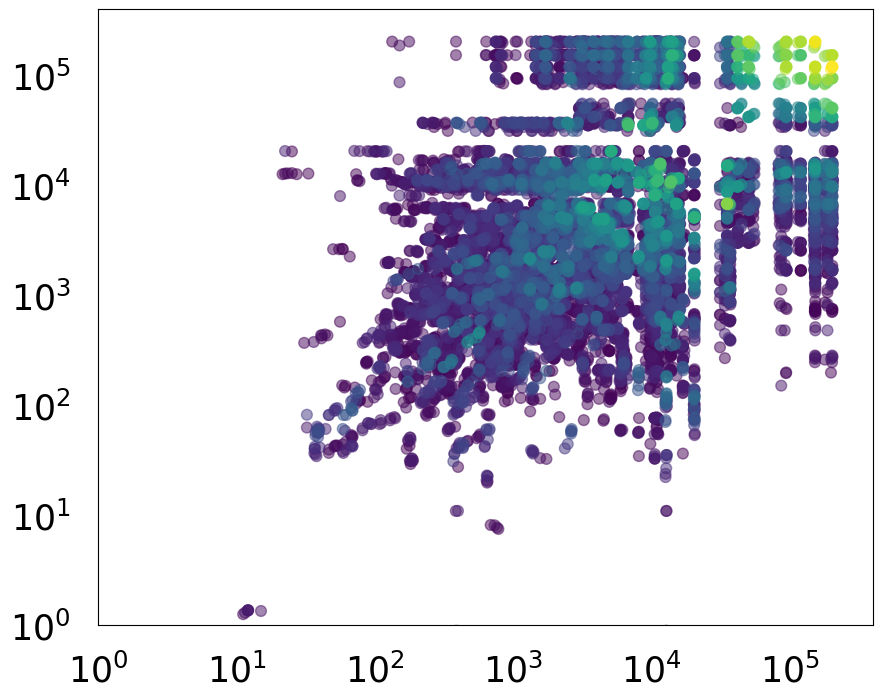

In [101]:
# Filter data to include only observed movements (obs == True) and perform some sanity checks
data_test = data[data['obs'] == True]

fig, ax = plt.subplots(figsize=(10, 8))
data_test = data_test.sort_values(by='y', ascending=True)
ax.tick_params(axis='both', which='both', width=0, length=0, color='k', labelsize=25, pad=20)
sc = ax.scatter(data_test['pop_O'], data_test['pop_D'], c=np.log10(data_test['y']), cmap='viridis', alpha=0.5, s=60)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([1, 400000])
ax.set_ylim([1, 400000])
# plt.savefig(wd + f'/plots/mov-data-obs-popOD/mov-data-obs-popOD-{country_short}.png', bbox_inches='tight')
plt.show()

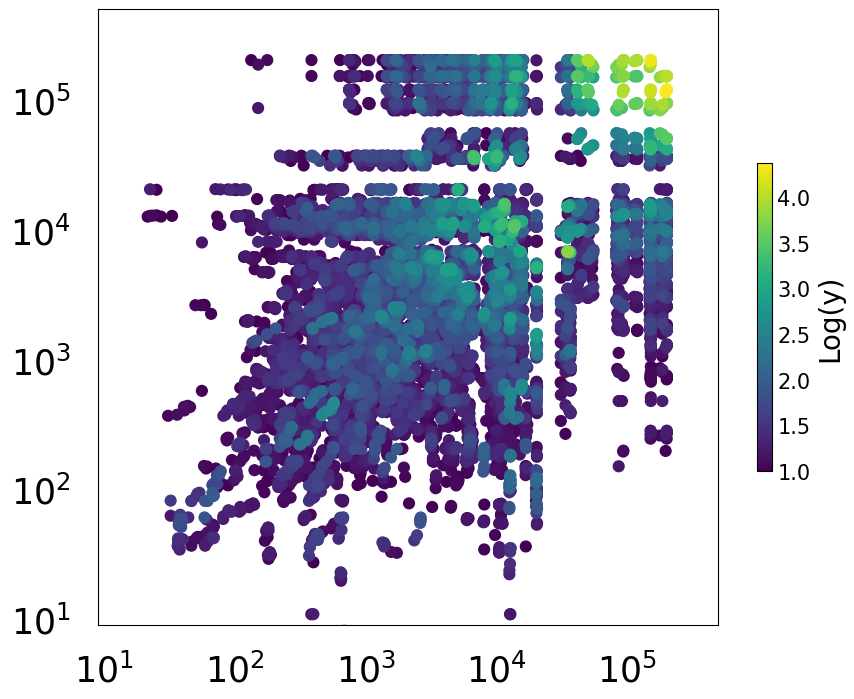

In [102]:
fig, ax = plt.subplots(figsize=(10, 8))
data_test = data_test.sort_values(by='y', ascending=True)
ax.tick_params(axis='both', which='both', width=0, length=0, color='k', labelsize=25, pad=20)
sc = ax.scatter(data_test['pop_O'], data_test['pop_D'], c=np.log10(data_test['y']), cmap='viridis', alpha=1, s=60)
ax.set_xscale('log')
ax.set_yscale('log')
cbar = plt.colorbar(sc, ax=ax, shrink=0.5)
cbar.set_label('Log(y)', fontsize=20)
cbar.ax.tick_params(labelsize=15, length=0)
ax.set_xlim([9, 500000])
ax.set_ylim([9, 500000])
# plt.savefig(wd + f'/plots/mov-data-obs-popOD/mov-data-obs-popOD-{country_short}-legend.png', bbox_inches='tight')
plt.show()


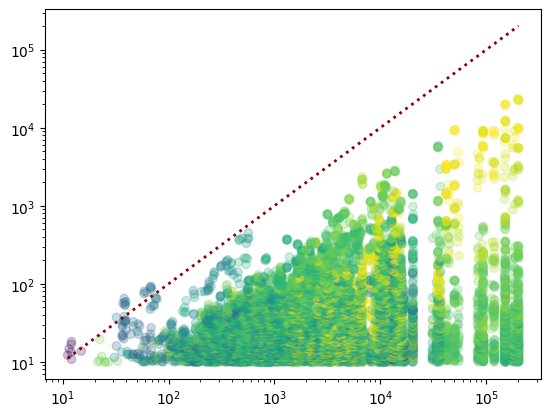

In [103]:
fig, ax = plt.subplots()
sc = ax.scatter(data_test['pop_O'], data_test['y'], c=np.log(data_test['pop_D']), cmap='viridis', alpha=0.25)
x = np.linspace(min(data_test['pop_O']), max(data_test['pop_O']))
ax.plot(x, x, lw=2, color='darkred', linestyle=':')
ax.set_xscale('log')
ax.set_yscale('log')
# plt.savefig(wd + f'/plots/mov-data-obs-popO-flow/mov-data-obs-popO-flow-{country_short}.pdf', bbox_inches='tight')
plt.show()


In [104]:
# Convert categorical variables to dummy/indicator variables
dummies_wday = pd.get_dummies(data['wday'], drop_first=True, dtype=int)

dummies_OD_class_density = pd.get_dummies(data['OD_class_density'], drop_first=True, dtype=int)
dummies_OD_class_rdi = pd.get_dummies(data['OD_class_rdi'], drop_first=True, dtype=int)

# Rename columns of dummies_OD_class_density to append suffix '_class_density'
dummies_OD_class_density = dummies_OD_class_density.rename(
    columns={col: str(int(col)) + '_class_density' for col in dummies_OD_class_density.columns}
)

# Rename columns of dummies_OD_class_rdi to append suffix '_class_rdi'
dummies_OD_class_rdi = dummies_OD_class_rdi.rename(
    columns={col: str(int(col)) + '_class_rdi' for col in dummies_OD_class_rdi.columns}
)

# Select relevant numeric columns from the original data
X = data[['dist', 'pop_O', 'pop_D', 'obs', 'y']]

# Concatenate weekday dummies with the selected numeric columns
X = pd.concat([dummies_wday, X], axis=1)

# Alternative concatenations commented out:
# - including other dummy variables for origin (O) and OD classes
# X = pd.concat([dummies_wday, X, dummies_O, dummies_OD_class_density, dummies_OD_class_rdi], axis=1)
# X = pd.concat([dummies_wday, X, dummies_O], axis=1)
# X = pd.concat([X], axis=1)

# Add constant term for intercept in regression models
X = sm.add_constant(X)

# Filter rows where 'dist', 'pop_O', and 'pop_D' are greater than zero
X = X[X['dist'] > 0].reset_index(drop=True)
X = X[X['pop_O'] > 0].reset_index(drop=True)
X = X[X['pop_D'] > 0].reset_index(drop=True)

# Subset observed data where 'obs' == True
X_obs = X[X['obs'] == True].reset_index(drop=True)

# Extract target variable 'y' for observed data
y_obs = X_obs['y']

# Drop columns not needed for modeling from observed dataset
X_obs = X_obs.drop(['obs', 'y'], axis=1)

# Prepare prediction dataset by dropping 'obs' and 'y' columns from full dataset
X_predict = X.drop(['obs', 'y'], axis=1)

# Drop rows with any missing values (NaNs) in the observed dataset
X_obs_dropna = X_obs.dropna()

# Optional filters commented out: only keep rows where population columns > 1
# X_obs_dropna = X_obs_dropna[X_obs_dropna['pop_O'] > 1]
# X_obs_dropna = X_obs_dropna[X_obs_dropna['pop_D'] > 1]

# Align target variable 'y_obs' with the filtered dataset using indices
y_obs_dropna = y_obs.iloc[X_obs_dropna.index].reset_index(drop=True)

# Reset index of the filtered dataset for clean indexing
X_obs_dropna = X_obs_dropna.reset_index(drop=True)

# Apply natural logarithm transformation to population and distance variables
X_obs_dropna['pop_O'] = np.log(X_obs_dropna['pop_O'])
X_obs_dropna['pop_D'] = np.log(X_obs_dropna['pop_D'])
X_obs_dropna['dist'] = np.log(X_obs_dropna['dist'])


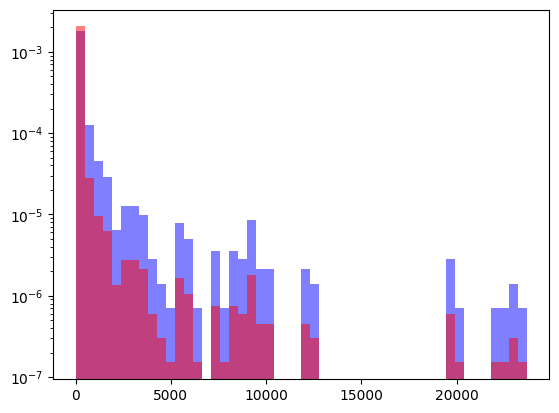

In [105]:
# Normalize the target variable to create sampling weights:
# Higher target values will have higher probability of being sampled.
# This helps avoid the sample being dominated by smaller values (e.g., below 10),
# which you can see by comparing histograms below.
prob_normalized = y_obs_dropna / y_obs_dropna.sum()

# Create a DataFrame for sampling purposes
sample_y_obs_dropna = pd.DataFrame({'y_obs_dropna': y_obs_dropna})

# Sample 3000 rows without replacement, weighted by the normalized target values
sample_y_obs_dropna = sample_y_obs_dropna.sample(
    n=3000,
    weights=prob_normalized,
    replace=False
)

# Plot histograms to compare the distribution of sampled vs. original target values
fig, ax = plt.subplots()
ax.hist(sample_y_obs_dropna['y_obs_dropna'], bins=50, color='blue', alpha=0.5, density=True, label='Sampled')
ax.hist(y_obs_dropna, bins=50, color='red', alpha=0.5, density=True, label='Original')
ax.set_yscale('log')
plt.show()


In [106]:
use_conservative_subunit_rule = True
output_suffix = '-subunit0' if use_conservative_subunit_rule else ''

# Different options form movel, best one is GLM

X_obs_dropna = X_obs_dropna.iloc[sample_y_obs_dropna.index]
y_obs_dropna = y_obs_dropna.iloc[sample_y_obs_dropna.index]


# def sse_log_a(a, Y, X):
#     log_aY = np.log(a * Y)
#     model = sm.GLM(log_aY, X, family=sm.families.NegativeBinomial(alpha=1))
#     res = model.fit()
#     opt = res.residual
#     print(opt)
#     return opt

# result = scipy.optimize.minimize(sse_log_a, x0=[12], args=(y_obs_dropna, X_obs_dropna), method='BFGS')
# a_estimated = result.x[0]
# print(f"Estimated value of a: {a_estimated}")

# log_aY = np.log(a_estimated * y_obs_dropna)
# model = sm.GLM(log_aY, X_obs_dropna, family=sm.families.NegativeBinomial(alpha=1))
# res = model.fit()
# print(res.summary())

model = sm.GLM(np.log(y_obs_dropna), X_obs_dropna, family=sm.families.Gaussian())
res = model.fit()
print(res.summary())

# model = sm.RLM(np.log(y_obs_dropna), X_obs_dropna, M=sm.robust.norms.HuberT())
# res = model.fit()
# print(res.summary())

# model = sm.GLM(np.log(y_obs_dropna), X_obs_dropna, family=sm.families.Gaussian(sm.families.links.identity()))
# res = model.fit(cov_type='HC3')
# print(res.summary())

# data_quantreg = X_obs_dropna.copy()
# data_quantreg['Y'] = np.log(y_obs_dropna)
# data_quantreg.columns = ['const', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'dist', 'pop_O', 'pop_D', 'Y']
# model = smf.quantreg('Y ~ const + d1 + d2 + d3 + d4 + d5 + d6 + dist + pop_O + pop_D', data=data_quantreg)
# res = model.fit(q=0.75)
# print(res.summary())

# model = sm.GLM(np.log(10*y_obs_dropna), X_obs_dropna, family=sm.families.Poisson())
# res = model.fit()
# llf_Poisson = res.llf

# model = sm.GLM(y_obs_dropna, X_obs_dropna, family=sm.families.NegativeBinomial(alpha=1))
# res = model.fit()
# llf_NB = res.llf

# # log likelihood ratio test
# logratio = -2 * (llf_Poisson - llf_NB)
# df = 1 # given the difference in dof
# # compute the p-value
# pvalue = 1 - scipy.stats.chi2(df).cdf(logratio) # since Λ follows χ2
# print('logratio', logratio, 'p-value', pvalue)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 3000
Model:                            GLM   Df Residuals:                     2990
Model Family:                Gaussian   Df Model:                            9
Link Function:               identity   Scale:                         0.97033
Method:                          IRLS   Log-Likelihood:                -4206.6
Date:                Mon, 30 Mar 2026   Deviance:                       2901.3
Time:                        13:32:01   Pearson chi2:                 2.90e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.7347
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.5256      0.267     39.362      0.0

In [107]:

# Drop rows with missing values in the prediction dataset and reset index
X_predict_dropna = X_predict.dropna().reset_index(drop=True)

# Apply log transformation to the relevant predictor variables
X_predict_dropna['pop_O'] = np.log(X_predict_dropna['pop_O'])
X_predict_dropna['pop_D'] = np.log(X_predict_dropna['pop_D'])
X_predict_dropna['dist'] = np.log(X_predict_dropna['dist'])

# Make a copy of the cleaned dataset for quantile regression
X_predict_dropna_quantreg = X_predict_dropna.copy()

# Use the fitted model to predict on the cleaned, log-transformed dataset
y_predict = res.predict(X_predict_dropna)

# Rename columns to match expected names for quantile regression model (if needed)
# X_predict_dropna_quantreg.columns = ['const', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'dist', 'pop_O', 'pop_D']
# Alternative prediction call for quantile regression dataset (commented out)
# y_predict = res.predict(X_predict_dropna_quantreg)


# Save values imputed according to SIM in standard and long format

In [108]:
# Create a copy of the target variable to store imputed values
data['y_imput'] = data['y']
data['subunit_rule_applied'] = False

# Initialise a counter for predictions
j = 0

# Iterate over the rows to replace '-1' values in 'y_imput' with predictions
for i in range(len(data)):
    if data.loc[i, 'y_imput'] == -1:
        # Impute missing values using the exponentiated predicted log-values
        pred_flow = np.exp(y_predict[j])
        if use_conservative_subunit_rule and pred_flow < 1:
            data.loc[i, 'y_imput'] = 0
            data.loc[i, 'subunit_rule_applied'] = True
        else:
            data.loc[i, 'y_imput'] = pred_flow
        j += 1
    else:
        # Keep original values if not '-1'
        data.loc[i, 'y_imput'] = data.loc[i, 'y']

# Optional: save the updated data to CSV 
data.to_csv(
    wd + '/data/outputs/' + country_short + '/baseline/'
    + 'movcell-baseline-imput-mov-dist-with-exo-var' + output_suffix + '-sample.csv',
    index=False
)


In [109]:
# Initialise counter for indexing into data['y_imput']
k = 0

# Make a copy of the baseline_mov_dist dataframe to perform imputations
baseline_mov_imput = baseline_mov_dist.copy()

# Iterate over rows and columns (columns named '0' to '6') to replace -1 with imputed values
for i in range(len(baseline_mov_imput)):
    for j in range(7):
        col = str(j)
        if baseline_mov_imput.loc[i, col] == -1:
            baseline_mov_imput.loc[i, col] = data.loc[k, 'y_imput']
        k += 1

# Optional: save the imputed DataFrame to CSV (commented out)
baseline_mov_imput.to_csv(
    wd + f'/data/outputs/{country_short}/baseline/'
    + 'movcell-baseline-imput-mov-dist-with-exo-var-flatten' + output_suffix + '-sample.csv',
    index=False
)


# A few tests to validate estimated baseline

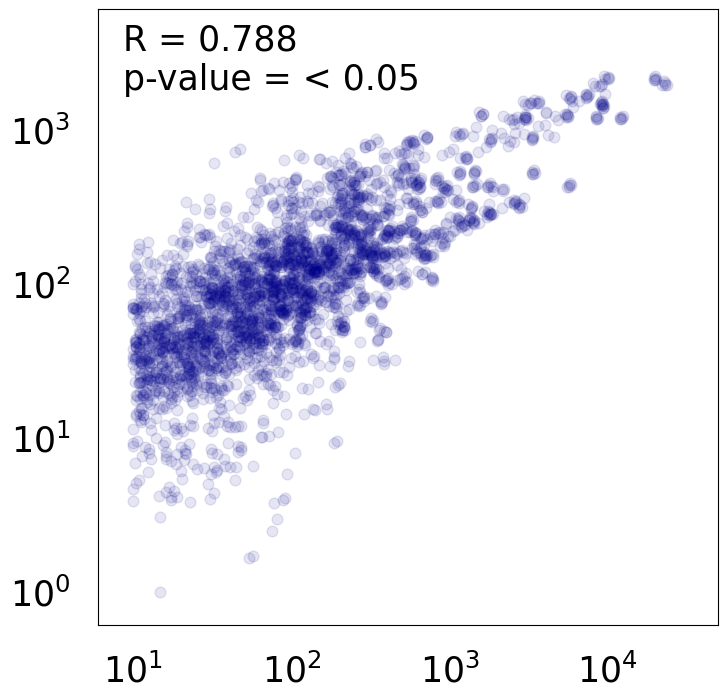

In [110]:
y_predict_test = pd.DataFrame({'y_predict_test': res.predict(X_obs_dropna)})

fig, ax = plt.subplots(figsize=(8,8))

ax.tick_params(axis = 'both', which = 'both', width = 0, length = 0, color = 'k', labelsize = 25, pad=20)

ax.scatter(y_obs_dropna, np.exp(y_predict_test['y_predict_test']), alpha=0.1, s=60, color='darkblue')

pearson = scipy.stats.pearsonr(y_obs_dropna, np.exp(y_predict_test['y_predict_test']))
R = str(round(pearson.statistic,3))
pvalue = str(round(pearson.pvalue,2))

if float(pvalue) < 0.05:
    pvalue = '< 0.05'
ax.text(0.04, 0.87, 'R = ' + R + '\np-value = ' + pvalue, transform=ax.transAxes, size=25)

ax.set_xlim([6,50000])
ax.set_ylim([0.6, 6000])
ax.set_xscale('log')
ax.set_yscale('log')

plt.savefig(wd + '/plots/mov-data-obs-pred-flow/mov-data-obs-pred-flow-' + country_short + '.png', bbox_inches = 'tight')

plt.show()

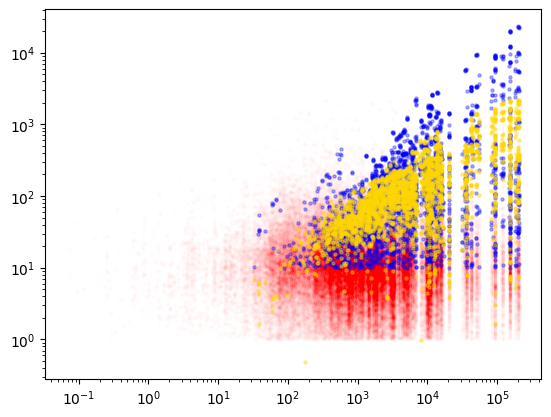

In [111]:
count_ovalue = 0
count_uvalue = 0
value = 10
for i in range(len(y_predict)):
    if np.exp(y_predict[i]) < value:
        count_uvalue += 1
    elif np.exp(y_predict[i]) >= value:
        count_ovalue += 1

fig, ax = plt.subplots()
ax.scatter(data[data['y']==-1]['pop_O'], data[data['y']==-1]['y_imput'], zorder=2, color='red', s=5, alpha=0.002)
ax.scatter(np.exp(X_obs_dropna['pop_O']), np.exp(y_predict_test), zorder=5, color='gold', s=5, alpha=0.4)
ax.scatter(np.exp(X_obs_dropna['pop_O']), y_obs_dropna, zorder= 4, color='blue', s=5, alpha=0.3)

# ax.set_xlim([-50000, 300000])
# ax.set_ylim([-100, 200])

ax.set_xscale('log')
ax.set_yscale('log')

plt.show()

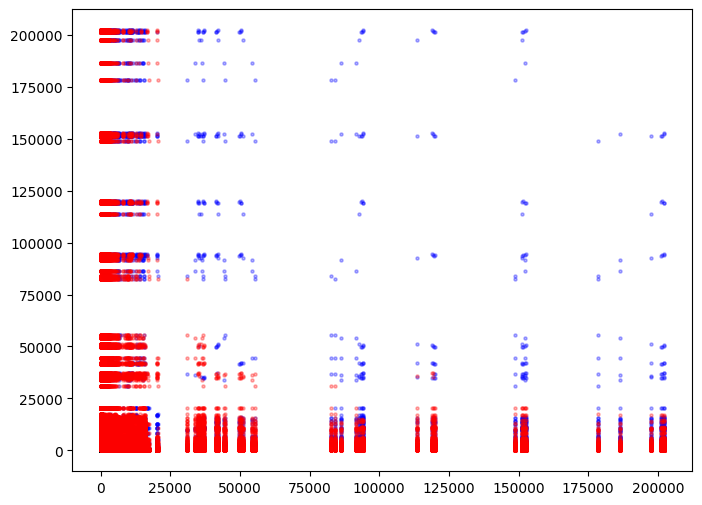

In [112]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_obs['pop_O'], X_obs['pop_D'], color='blue', s=5, alpha=0.3, label='Observed')
ax.scatter(data[data['y'] == -1]['pop_O'], data[data['y'] == -1]['pop_D'], color='red', s=5, alpha=0.3, label='Missing')
plt.show()

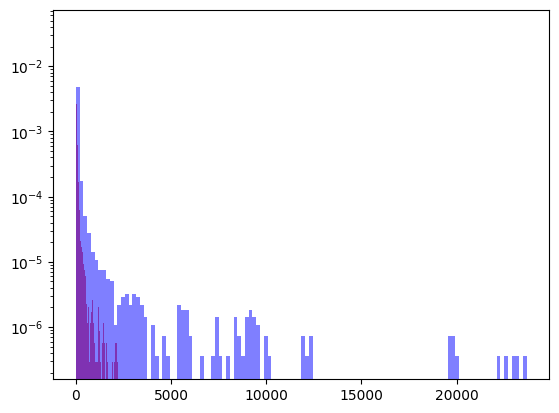

In [113]:
fig, ax = plt.subplots()
ax.hist(data[data['y']>-1]['y_imput'], bins=120, density=True, color='blue', alpha=0.5, zorder=3)
ax.hist(data[data['y']==-1]['y_imput'], bins=120, density=True, color='red', alpha=0.6, zorder=2)
ax.set_yscale('log')
plt.show()

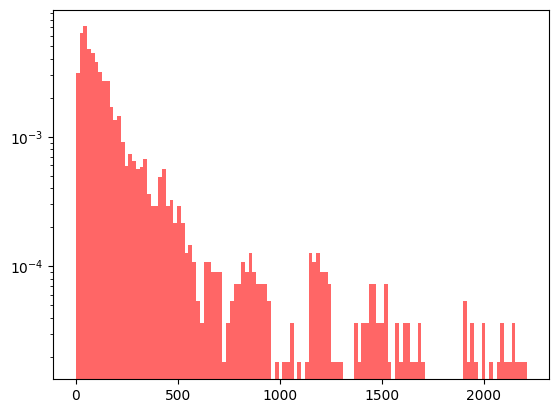

In [114]:
fig, ax = plt.subplots()
# ax.hist(data[data['y']>-1]['y_imput'], bins=120, density=True, color='blue', alpha=0.5, zorder=3)
ax.hist(np.exp(y_predict_test), bins=120, density=True, color='red', alpha=0.6, zorder=2)
ax.set_yscale('log')
# ax.set_xscale('log')
plt.show()